# Flow-barrier pumping sensitivity

Compare `5_year_pumping_tests` / `pumping_1e-6` across Potomac domains that differ only in the FlowBarrierZ multiplier (values in each run's `pf_flowbarrier.pfb`):

| Domain | Barrier value |
|--------|---------------|
| `potomac2` | 0.001 (CONUS default) |
| `potomac_flow_barrier_0011` | 0.0011 |
| `potomac_flow_barrier_002` | 0.002 |
| `potomac_flow_barrier_005` | 0.005 |

Sequence: **5 yr** average spinup → **3 yr** pumping at domain-average `1e-6` m/h.

`potomac_flow_barrier_0015` (0.0015) has no finished `5_year_pumping_tests` output yet and is omitted.

Uses `utils.read_storage_outlet_series` (storage + outlet only).

In [1]:
try:
    from drought_ensemble.analysis.paper_figures import utils
except ImportError:
    import sys
    from pathlib import Path

    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))

    from analysis.paper_figures import utils

In [2]:
import configparser
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ENSEMBLE = "5_year_pumping_tests"
MEMBER = "pumping_1e-6"
PROJECT_ROOT = Path("/glade/derecho/scratch/bwest/drought-ensemble")

# Domain name → FlowBarrierZ multiplier used in that domain's runs
DOMAINS = {
    "potomac2": 0.001,
    "potomac_flow_barrier_0011": 0.0011,
    "potomac_flow_barrier_002": 0.002,
    "potomac_flow_barrier_005": 0.005,
}

SPINUP_YEARS = 5
SPINUP_YEARS_TO_KEEP = 2
PLOT_START_YEAR = SPINUP_YEARS - SPINUP_YEARS_TO_KEEP  # 3
PUMPING_START_YEAR = SPINUP_YEARS  # 5
INTERVAL = 219  # hours (~9-day sampling)

FIG_DIR = PROJECT_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

outlets = {}
for domain_name in DOMAINS:
    cfg = configparser.ConfigParser()
    cfg_path = PROJECT_ROOT / "domains" / domain_name / "config.ini"
    if not cfg.read(cfg_path):
        raise FileNotFoundError(cfg_path)
    outlets[domain_name] = (
        int(cfg.get("DEFAULT", "OUTLET_X")),
        int(cfg.get("DEFAULT", "OUTLET_Y")),
    )
    print(
        f"{domain_name}: barrier={DOMAINS[domain_name]}  "
        f"outlet={outlets[domain_name]}"
    )

potomac2: barrier=0.001  outlet=(66, 135)
potomac_flow_barrier_0011: barrier=0.0011  outlet=(66, 135)
potomac_flow_barrier_002: barrier=0.002  outlet=(66, 135)
potomac_flow_barrier_005: barrier=0.005  outlet=(66, 135)


In [3]:
def barrier_label(domain_name: str) -> str:
    v = DOMAINS[domain_name]
    if domain_name == "potomac2":
        return f"potomac2 ({v:g})"
    return f"{v:g}"


def delta_from_onset(da, onset_year=PUMPING_START_YEAR):
    t = da.time.values
    i0 = int(np.argmin(np.abs(t - onset_year)))
    return da - float(da.isel(time=i0).values)


series = {}
for domain_name in DOMAINS:
    ox, oy = outlets[domain_name]
    print(f"Loading {domain_name}/{MEMBER}…", flush=True)
    ds = utils.read_storage_outlet_series(
        ENSEMBLE,
        MEMBER,
        domain_name,
        start_year=PLOT_START_YEAR,
        interval=INTERVAL,
        outlet_x=ox,
        outlet_y=oy,
    )
    series[domain_name] = ds
    print(
        f"  time {float(ds.time.min()):.2f} → {float(ds.time.max()):.2f} yr "
        f"({ds.sizes['time']} samples)",
        flush=True,
    )

Loading potomac2/pumping_1e-6…


  time 3.00 → 7.97 yr (200 samples)


Loading potomac_flow_barrier_0011/pumping_1e-6…


  time 3.00 → 7.97 yr (200 samples)


Loading potomac_flow_barrier_002/pumping_1e-6…


  time 3.00 → 7.97 yr (200 samples)


Loading potomac_flow_barrier_005/pumping_1e-6…


  time 3.00 → 7.97 yr (200 samples)


## Storage and outlet flow

Last 2 spinup years + 3 pumping years. Vertical line marks pumping onset (year 5).

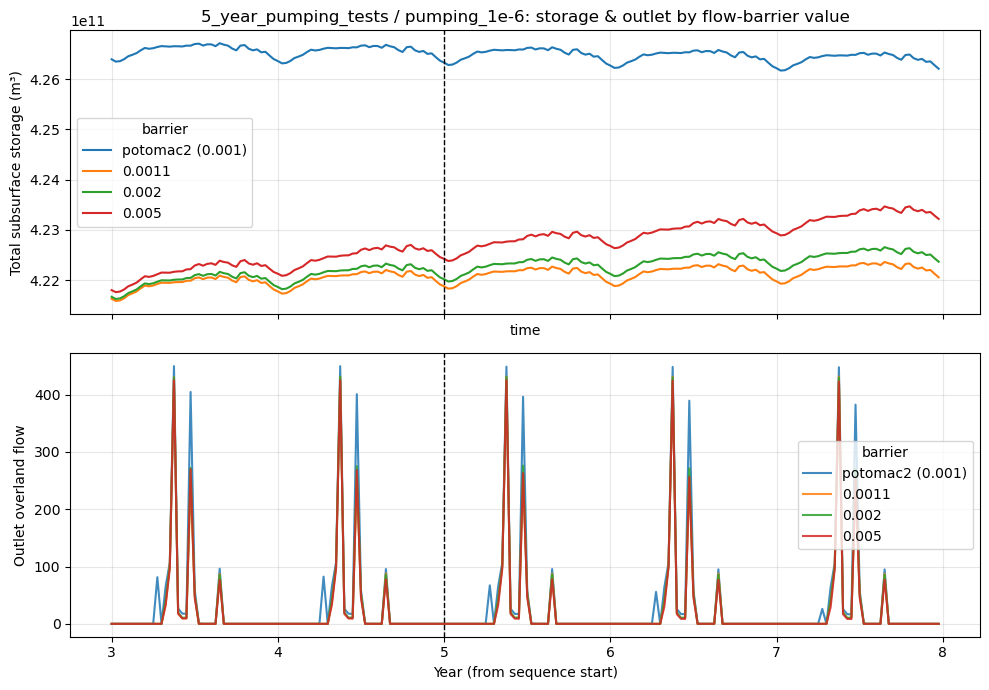

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for domain_name, ds in series.items():
    label = barrier_label(domain_name)
    ds.storage.plot(ax=axes[0], label=label)
    ds.outlet_flow.plot(ax=axes[1], label=label, alpha=0.85)

for ax in axes:
    ax.axvline(PUMPING_START_YEAR, color="k", ls="--", lw=1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Total subsurface storage (m³)")
axes[0].set_title(
    f"{ENSEMBLE} / {MEMBER}: storage & outlet by flow-barrier value"
)
axes[0].legend(title="barrier", loc="best")

axes[1].set_ylabel("Outlet overland flow")
axes[1].set_xlabel("Year (from sequence start)")
axes[1].legend(title="barrier", loc="best")

plt.tight_layout()
fig.savefig(FIG_DIR / "flow_barrier_pumping_storage_outlet.png", dpi=150)
plt.show()

## Change after pumping starts

Anomalies relative to the sample nearest pumping onset remove different spinup levels so barrier effects on the pumping response are easier to compare.

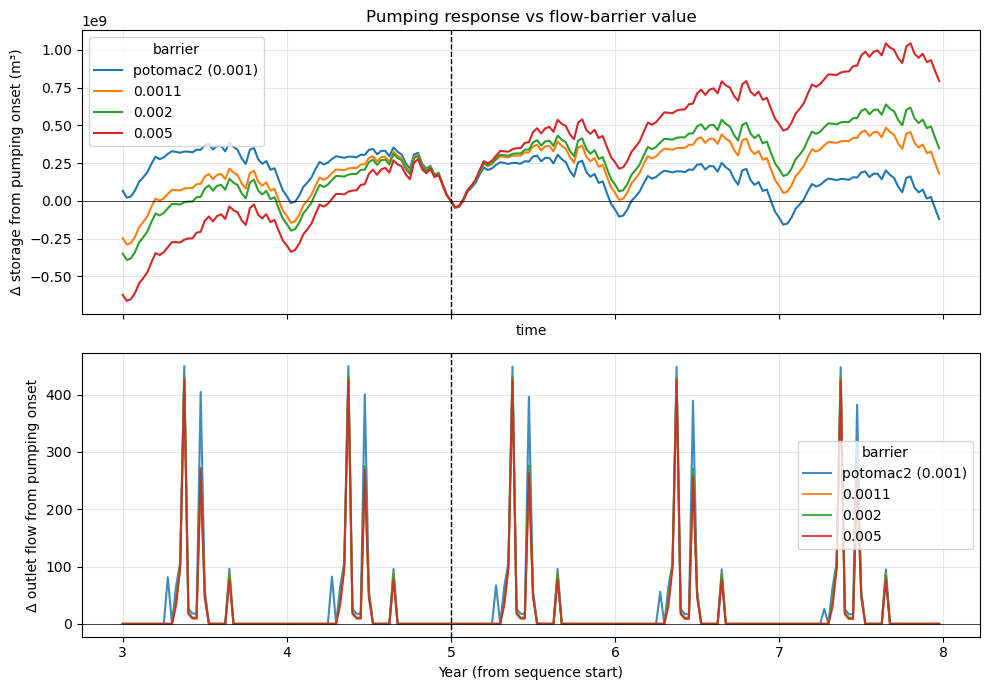

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for domain_name, ds in series.items():
    label = barrier_label(domain_name)
    delta_from_onset(ds.storage).plot(ax=axes[0], label=label)
    delta_from_onset(ds.outlet_flow).plot(ax=axes[1], label=label, alpha=0.85)

for ax in axes:
    ax.axvline(PUMPING_START_YEAR, color="k", ls="--", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Δ storage from pumping onset (m³)")
axes[0].set_title("Pumping response vs flow-barrier value")
axes[0].legend(title="barrier", loc="best")

axes[1].set_ylabel("Δ outlet flow from pumping onset")
axes[1].set_xlabel("Year (from sequence start)")
axes[1].legend(title="barrier", loc="best")

plt.tight_layout()
fig.savefig(FIG_DIR / "flow_barrier_pumping_anomalies.png", dpi=150)
plt.show()

## Detrended storage response

Subtract each domain's linear pre-pumping storage trend so the curves show pumping impact relative to continued spinup, not absolute storage change.

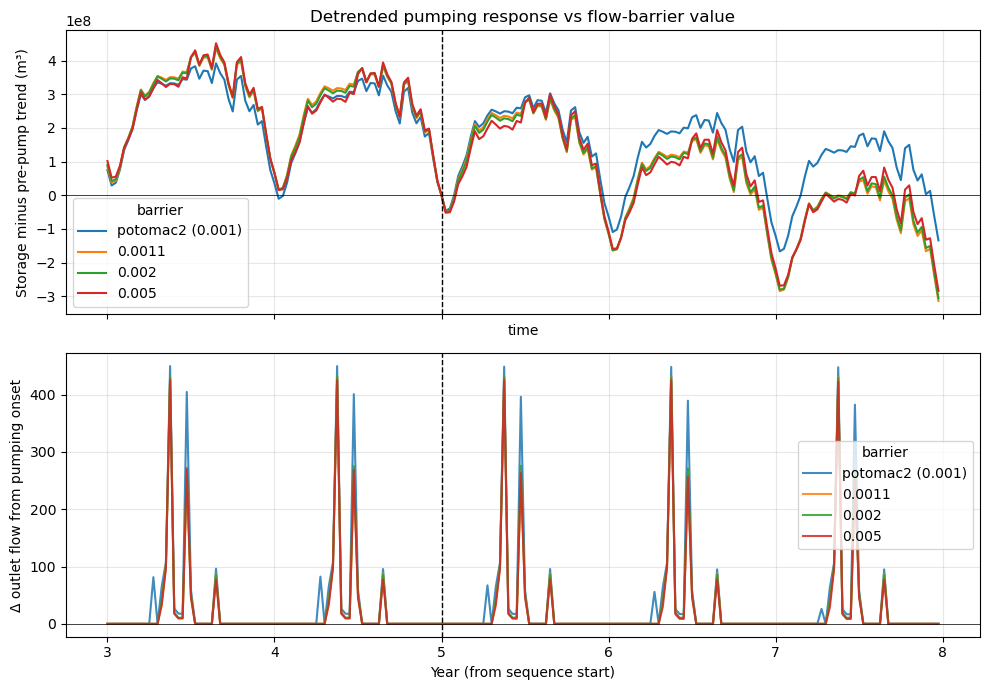

In [6]:
def detrended_from_onset(da, onset_year=PUMPING_START_YEAR, fit_start=PLOT_START_YEAR):
    """Anomaly vs linear pre-pumping trend continued past onset."""
    t = da.time.values
    y = da.values.astype(float)
    pre = (t >= fit_start) & (t < onset_year)
    a, c = np.polyfit(t[pre], y[pre], 1)
    i0 = int(np.argmin(np.abs(t - onset_year)))
    # trend anchored at onset value for continuity at t0
    trend = y[i0] + a * (t - t[i0])
    return da.copy(data=y - trend)


fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for domain_name, ds in series.items():
    label = barrier_label(domain_name)
    detrended_from_onset(ds.storage).plot(ax=axes[0], label=label)
    delta_from_onset(ds.outlet_flow).plot(ax=axes[1], label=label, alpha=0.85)

for ax in axes:
    ax.axvline(PUMPING_START_YEAR, color="k", ls="--", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Storage minus pre-pump trend (m³)")
axes[0].set_title("Detrended pumping response vs flow-barrier value")
axes[0].legend(title="barrier", loc="best")

axes[1].set_ylabel("Δ outlet flow from pumping onset")
axes[1].set_xlabel("Year (from sequence start)")
axes[1].legend(title="barrier", loc="best")

plt.tight_layout()
fig.savefig(FIG_DIR / "flow_barrier_pumping_detrended.png", dpi=150)
plt.show()


## Sensitivity summary

**Raw** end-of-run Δstorage conflates ongoing spinup with pumping: leakier barriers still gain storage over the short 5-yr spinup, so raw ΔS can be positive even while pumping.

**Detrended** metrics isolate the pumping response by subtracting the linear pre-pumping storage trend extrapolated through the pumping years:

- `detrend_ΔS` = observed end storage − expected if pre-pumping `dS/dt` continued
- `Δrate` = `dS/dt` during pumping − `dS/dt` before pumping

Larger barrier values = leakier vertical connection through the flow-barrier face.

potomac2                         barrier=0.001  raw_ΔS=-1.212e+08  detrend_ΔS=-1.338e+08  Δ(dS/dt)=-4.081e+07  outlet Δ=-1.3
potomac_flow_barrier_0011        barrier=0.0011  raw_ΔS=+1.803e+08  detrend_ΔS=-3.138e+08  Δ(dS/dt)=-1.009e+08  outlet Δ=+0.257
potomac_flow_barrier_002         barrier=0.002  raw_ΔS=+3.481e+08  detrend_ΔS=-3.057e+08  Δ(dS/dt)=-9.699e+07  outlet Δ=-0.00508
potomac_flow_barrier_005         barrier=0.005  raw_ΔS=+7.937e+08  detrend_ΔS=-2.841e+08  Δ(dS/dt)=-8.701e+07  outlet Δ=-0.398


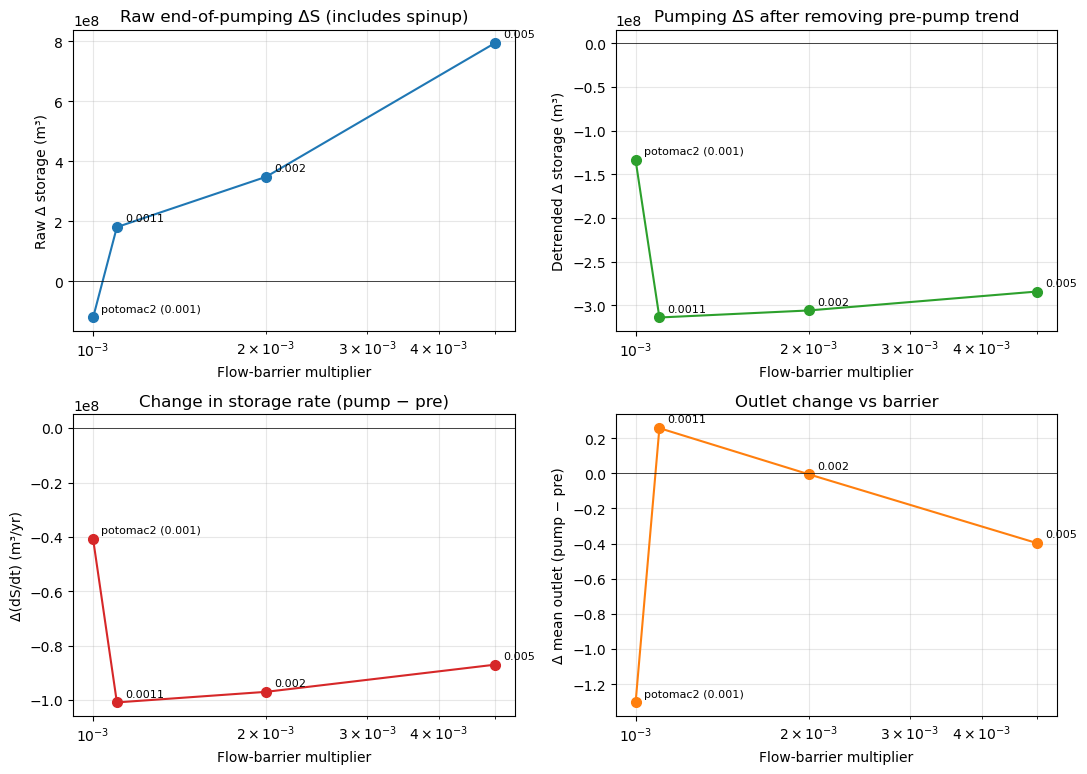

In [7]:
rows = []
for domain_name, ds in series.items():
    barrier = DOMAINS[domain_name]
    t = ds.time.values
    s = ds.storage.values.astype(float)
    q = ds.outlet_flow.values.astype(float)
    pump = t >= PUMPING_START_YEAR
    pre = (t >= PLOT_START_YEAR) & (t < PUMPING_START_YEAR)

    i0 = int(np.argmin(np.abs(t - PUMPING_START_YEAR)))
    end_delta_s = float(s[-1] - s[i0])

    a_pre = float(np.polyfit(t[pre], s[pre], 1)[0])
    a_pump = float(np.polyfit(t[pump], s[pump], 1)[0])
    expected_end = s[i0] + a_pre * (t[-1] - t[i0])
    detrend_delta_s = float(s[-1] - expected_end)

    mean_flow_pre = float(q[pre].mean())
    mean_flow_pump = float(q[pump].mean())
    rows.append(
        {
            "domain": domain_name,
            "barrier": barrier,
            "end_delta_storage_m3": end_delta_s,
            "detrend_delta_storage_m3": detrend_delta_s,
            "dsdt_pre": a_pre,
            "dsdt_pump": a_pump,
            "delta_dsdt": a_pump - a_pre,
            "mean_outlet_pre": mean_flow_pre,
            "mean_outlet_pump": mean_flow_pump,
            "delta_mean_outlet": mean_flow_pump - mean_flow_pre,
        }
    )

rows = sorted(rows, key=lambda r: r["barrier"])
for r in rows:
    print(
        f"{r['domain']:32s} barrier={r['barrier']:.4g}  "
        f"raw_ΔS={r['end_delta_storage_m3']:+.3e}  "
        f"detrend_ΔS={r['detrend_delta_storage_m3']:+.3e}  "
        f"Δ(dS/dt)={r['delta_dsdt']:+.3e}  "
        f"outlet Δ={r['delta_mean_outlet']:+.3g}"
    )

barriers = [r["barrier"] for r in rows]
labels = [barrier_label(r["domain"]) for r in rows]
raw_s = [r["end_delta_storage_m3"] for r in rows]
detrend_s = [r["detrend_delta_storage_m3"] for r in rows]
delta_rate = [r["delta_dsdt"] for r in rows]
delta_q = [r["delta_mean_outlet"] for r in rows]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(barriers, raw_s, "o-", ms=7)
for x, y, lab in zip(barriers, raw_s, labels):
    axes[0, 0].annotate(lab, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0, 0].axhline(0, color="k", lw=0.5)
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("Flow-barrier multiplier")
axes[0, 0].set_ylabel("Raw Δ storage (m³)")
axes[0, 0].set_title("Raw end-of-pumping ΔS (includes spinup)")
axes[0, 0].grid(True, alpha=0.3, which="both")

axes[0, 1].plot(barriers, detrend_s, "o-", ms=7, color="C2")
for x, y, lab in zip(barriers, detrend_s, labels):
    axes[0, 1].annotate(lab, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0, 1].axhline(0, color="k", lw=0.5)
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("Flow-barrier multiplier")
axes[0, 1].set_ylabel("Detrended Δ storage (m³)")
axes[0, 1].set_title("Pumping ΔS after removing pre-pump trend")
axes[0, 1].grid(True, alpha=0.3, which="both")

axes[1, 0].plot(barriers, delta_rate, "o-", ms=7, color="C3")
for x, y, lab in zip(barriers, delta_rate, labels):
    axes[1, 0].annotate(lab, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1, 0].axhline(0, color="k", lw=0.5)
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("Flow-barrier multiplier")
axes[1, 0].set_ylabel("Δ(dS/dt) (m³/yr)")
axes[1, 0].set_title("Change in storage rate (pump − pre)")
axes[1, 0].grid(True, alpha=0.3, which="both")

axes[1, 1].plot(barriers, delta_q, "o-", ms=7, color="C1")
for x, y, lab in zip(barriers, delta_q, labels):
    axes[1, 1].annotate(lab, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1, 1].axhline(0, color="k", lw=0.5)
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("Flow-barrier multiplier")
axes[1, 1].set_ylabel("Δ mean outlet (pump − pre)")
axes[1, 1].set_title("Outlet change vs barrier")
axes[1, 1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
fig.savefig(FIG_DIR / "flow_barrier_pumping_sensitivity_summary.png", dpi=150)
plt.show()
